# Section 1: Data Ingestion, Quality Filtering, and 3D Spatial Mapping

This initialization section sets up our scientific computing environment, cleans the raw telescope data, and builds the physical coordinate skeleton of our universe map. 

### Implementation & Physics Pipeline
Using `NumPy` and `Astropy`, the pipeline first loads the raw, 3.6-million-row DESI spectroscopic catalog (`.fits` table) from the supercomputer storage directory into active memory. It immediately runs a multi-variable quality assurance filter to strip out corrupt tracking anomalies (where `ZWARN != 0`) and internal Milky Way stellar targets (`SPECTYPE == 'STAR'`), successfully isolating purely clean, extragalactic structures.

Because graphics engines like OpenSpace render points in flat Euclidean vector space rather than angles, the pipeline uses the `Planck18` cosmology profile to calculate each object's actual **Comoving Distance** based on its look-back redshift.


Using these computed distances, the native spherical coordinates (Right Ascension and Declination) are systematically projected into standardized 3D Cartesian coordinates ($x, y, z$) measured in megaparsecs ($\text{Mpc}$):



### The Big Picture
This single continuous workflow takes raw, multi-dimensional telescope parameters and flattens them into a precise 3D spatial coordinate grid. This file structures the physical cosmic web that audiences will fly through in the planetarium dome.

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table   
from astropy.coordinates import SkyCoord     
from astropy import units as u                   
from astropy.cosmology import Planck18 as cosmo
from astropy.table import unique
from astropy.visualization import make_lupton_rgb
from scipy.stats import binned_statistic

In [2]:
#read in the catalog
path_to_catalog = '/users/PCON0003/ulricclaar/desi-openspace-visualization/zall-pix-iron.fits'  
catalog = Table.read(path_to_catalog)
print('Total number of objects:', len(catalog))

Total number of objects: 28425963


In [3]:
# Filter out entries with ZWARN != 0
if 'ZWARN' in catalog.colnames:
    catalog = catalog[catalog['ZWARN'] == 0]

#Filter out high ZERR values
if 'ZERR' in catalog.colnames:
    catalog = catalog[catalog['ZERR'] < 0.001]

# Delta Chi-Squared Cut (High Confidence Redshifts)
deltachi2_min = 40
catalog = catalog[catalog['DELTACHI2'] > deltachi2_min]

#Filter out duplicates
catalog = unique(catalog, keys=['TARGET_RA', 'TARGET_DEC'])
print('Objects kept:', len(catalog))

Objects kept: 18849581


In [4]:
# Trim catalog
RA_max = 360
RA_min = 0
DEC_max = 90
DEC_min = -90
catalog = catalog[(catalog['TARGET_RA'] < RA_max) & (catalog['TARGET_RA'] > RA_min) & (catalog['TARGET_DEC'] < DEC_max) & (catalog['TARGET_DEC'] > DEC_min)]
print('Objects kept:', len(catalog))
# Limit redshift
z_min = 0.01 # Below this, they're mostly stars or errors
z_max = 3    # DESI goes higher than this, but it is sparse and harder to visualize
catalog = catalog[(catalog['Z'] > z_min) & (catalog['Z'] < z_max)]
print('Objects kept:', len(catalog))
# Remove galaxies with unrealisting imaging fluxes
flux_g_max = 50  # These are quite faint. You calso can't have negative flux!
flux_g_min = 0
flux_r_max = 50  
flux_r_min = 0
flux_z_max = 50  
flux_z_min = 0
flux_W1_max = 50  
#flux_W1_min = 0
safe_flux_W1 = np.clip(catalog['FLUX_W1'], 0.001, None)
flux_W2_max = 50  
#flux_W2_min = 0
safe_flux_W2 = np.clip(catalog['FLUX_W2'], 0.001, None)

#catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W1'] > flux_W1_min) & (catalog['FLUX_W2'] < flux_W2_max) & (catalog['FLUX_W2'] > flux_W2_min)]
catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W2'] < flux_W2_max)]


print('Objects kept:', len(catalog))

Objects kept: 18849581
Objects kept: 14344852
Objects kept: 10053068


In [5]:
comoving_distance = cosmo.comoving_distance(catalog['Z'])  # Calculate the comoving distance to each object based on its redshift and the cosmology
coords = SkyCoord(ra=catalog['TARGET_RA'].value * u.degree, dec=catalog['TARGET_DEC'].value * u.degree, distance=comoving_distance) 
print('Objects kept:', len(catalog)) # Astropy converts this into a 3D coordinate system

Objects kept: 10053068


In [6]:
#Define 3d coords
x = coords.cartesian.x  # These are still astropy objects, i.e. they have assigned units (Mpc)
y = coords.cartesian.y
z = coords.cartesian.z
print('Objects kept:', len(catalog))

Objects kept: 10053068


# Section 2: Photometric Metrics & Reddening Bias Correction

This section extracts the telescope's raw energy metrics and mathematically scales them to isolate the intrinsic colors of every galaxy in the survey.

### Implementation & Physics Pipeline
Using standard photometric conversions, the pipeline translates raw fluxes into logarithmic Apparent Magnitudes, and subsequently uses Astropy's `luminosity_distance` metric to derive their **Absolute Magnitudes**, which is the true intrinsic brightness of the objects independent of their distance from Earth. 

When plotting uncorrected colors against distance, a prominent look-back time bias appears: distant galaxies appear artificially redder due to selection constraints and cosmological stellar evolution. To correct for this, the pipeline runs a linear least-squares regression (`np.polyfit`) across normal galaxies ($z < 0.8$) to measure this reddening trend line. It then dynamically subtracts this directional bias from every row, generating a newly flattened `corrected_color` parameter.

### The Big Picture
By mathematically flattening the look-back color bias, an object's color is no longer dictated by how far it is from our telescope. This correction unlocks a pristine view of the **Color-Magnitude Diagram**, cleanly splitting the universe into two distinct populations: the active star-forming "Blue Cloud" and the passively aging "Red Sequence."

In [7]:
#Define redshift and fluxes
redshift = catalog['Z'] 
flux_g = catalog['FLUX_G']
flux_r = catalog['FLUX_R']
flux_z = catalog['FLUX_Z']
flux_w1 = catalog['FLUX_W1']
flux_w2 = catalog['FLUX_W2']
#xtra
object_type = catalog['SPECTYPE']
zerr = catalog['ZERR']
zwarn = catalog['ZWARN']
print('Objects kept:', len(catalog))

Objects kept: 10053068


In [ ]:
#Define apparent magnitudes
app_mag_G = -2.5*np.log10(catalog['FLUX_G'])+22.5 
app_mag_R = -2.5*np.log10(catalog['FLUX_R'])+22.5 
app_mag_Z = -2.5*np.log10(catalog['FLUX_Z'])+22.5 
#app_mag_W1 = -2.5*np.log10(catalog['FLUX_W1'])+22.5
#app_mag_W2 = -2.5*np.log10(catalog['FLUX_W2'])+22.5
app_mag_W1 = -2.5 * np.log10(np.clip(catalog['FLUX_W1'], 0.001, None)) + 22.5
app_mag_W2 = -2.5 * np.log10(np.clip(catalog['FLUX_W2'], 0.001, None)) + 22.5
print('Objects kept:', len(catalog))

Objects kept: 10053068


: 

In [ ]:
#Define absolute magnitudes
def apparent_to_absolute_magnitude(m, z):
    d_L = cosmo.luminosity_distance(z)  
    M = m - 5 * np.log10(d_L.to(u.pc).value) + 5  
    return M
abs_mag_g = apparent_to_absolute_magnitude(app_mag_G, redshift)
abs_mag_r = apparent_to_absolute_magnitude(app_mag_R, redshift)
abs_mag_z = apparent_to_absolute_magnitude(app_mag_Z, redshift)
abs_mag_w1 = apparent_to_absolute_magnitude(app_mag_W1, redshift)
abs_mag_w2 = apparent_to_absolute_magnitude(app_mag_W2, redshift)
print('Objects kept:', len(catalog))

In [ ]:
from kcorrect.kcorrect import Kcorrect

# 1. Filter your existing 'catalog' for valid galaxies
valid = (catalog['SPECTYPE'] == 'GALAXY') & (catalog['ZWARN'] == 0) & (catalog['Z'] > 0)
galaxies = catalog[valid]

redshifts = galaxies['Z']
print('Step 1 completed: Filtered galaxies and extracted redshifts.')
# 2. Extract and convert photometry (nanomaggies to maggies)
maggies = np.column_stack([
    galaxies['FLUX_G'] * 1e-9,
    galaxies['FLUX_R'] * 1e-9,
    galaxies['FLUX_Z'] * 1e-9
])

# Convert inverse variances (scale by 1e18)
maggies_ivar = np.column_stack([
    galaxies['FLUX_IVAR_G'] * 1e18,
    galaxies['FLUX_IVAR_R'] * 1e18,
    galaxies['FLUX_IVAR_Z'] * 1e18
])
print('Step 2 completed: Extracted and converted photometry to maggies and inverse variances.')
# 3. Initialize the Kcorrect object and fit the templates
kc = Kcorrect(responses=['decam_g', 'decam_r', 'decam_z'])
coeffs = kc.fit_coeffs(redshift=redshifts, maggies=maggies, ivar=maggies_ivar)
print('Step 3 completed: Initialized Kcorrect and fitted templates to obtain coefficients.')
# 4. Calculate Absolute Magnitudes natively
# In kcorrect v5, this one line handles the K-correction, the distance modulus, 
# and the Planck18 cosmology calculations all at once!
absolute_mags = kc.absmag(redshift=redshifts, maggies=maggies, ivar=maggies_ivar, coeffs=coeffs)
print('Step 4 completed: Calculated absolute magnitudes using Kcorrect.')
# 5. Extract r-band (index 1) and z-band (index 2)
galaxies['ABS_MAG_R'] = absolute_mags[:, 1]
galaxies['ABS_MAG_Z'] = absolute_mags[:, 2]
print('Step 5 completed: Extracted r-band and z-band absolute magnitudes.')
# 6. Calculate the rest-frame color for your graphs
galaxies['REST_COLOR_RZ'] = galaxies['ABS_MAG_R'] - galaxies['ABS_MAG_Z']
print('Step 6 completed: Calculated rest-frame color (r - z) for galaxies.')

Step 1 completed: Filtered galaxies and extracted redshifts.
Step 2 completed: Extracted and converted photometry to maggies and inverse variances.


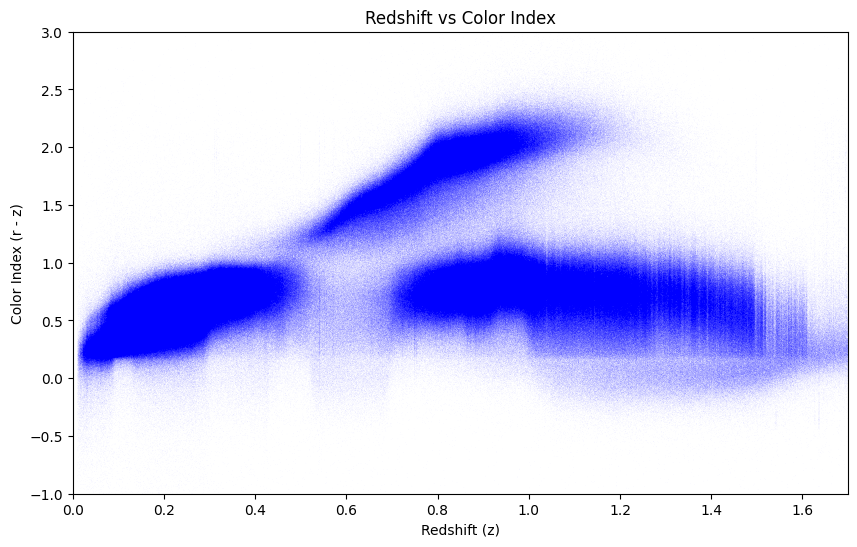

In [ ]:
color_index = abs_mag_r - abs_mag_z
redshift = catalog['Z']

plt.figure(figsize=(10, 6))

plt.scatter(redshift, color_index, s=0.1, alpha=0.1, color='blue', edgecolors='none')

plt.xlabel('Redshift (z)')
plt.ylabel('Color Index (r - z)')
plt.title('Redshift vs Color Index')

plt.ylim(-1, 3)
plt.xlim(0, 1.7)
plt.show()

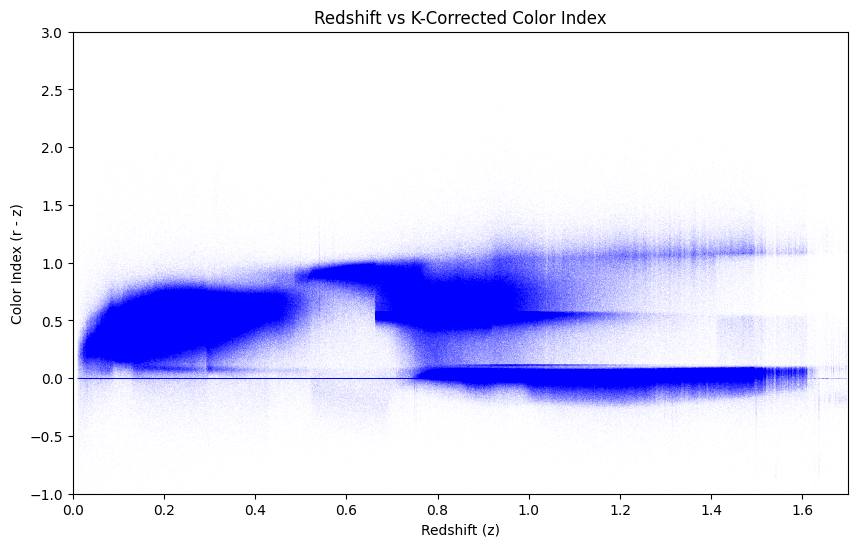

In [ ]:


plt.figure(figsize=(10, 6))

plt.scatter(galaxies['Z'], galaxies['REST_COLOR_RZ'], s=0.1, alpha=0.1, color='blue', edgecolors='none')

plt.xlabel('Redshift (z)')
plt.ylabel('Color Index (r - z)')
plt.title('Redshift vs K-Corrected Color Index')

plt.ylim(-1, 3)
plt.xlim(0, 1.7)
plt.show()

# Section 3: True Color Visual Compositing (Lupton RGB Engine)

This phase handles the creative translation of scientific wavelengths into vibrant, true-to-life RGB color data compatible with standard graphics rendering.

### Implementation & Physics Pipeline
To accurately map colors to actual human perception, the pipeline converts our corrected absolute magnitudes back into linear physical luminosities. These intensities are fed into Astropy's `make_lupton_rgb` compositing engine. This algorithm utilizes an asymmetrical arcsinh stretch mapping technique, stabilizing color ratios and keeping highly luminous objects from clipping into flat, oversaturated white pixels. To ensure star-forming regions pop realistically in a pitch-black planetarium dome, a targeted $1.5\times$ scaling factor is applied directly to the blue channel.

### The Big Picture
This section maps multi-wavelength astrophysics data onto a cohesive, visually appealing palette. It generates individual red, green, and blue parameters (`color_r`, `color_g`, `color_b`) for every object, providing the exact color logic OpenSpace needs to paint organic, true-color galaxy populations across the cosmic web.

In [ ]:
# Convert absolute magnitudes back to intrinsic linear luminosities
lum_r = 10 ** (-0.4 * abs_mag_r)
lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
norm = np.percentile(lum_r, 5)
lum_r = lum_r / norm
lum_g = lum_g / norm

# Map to RGB with a Blue Boost
rest_R = lum_r
rest_G = (lum_r + lum_g) / 2.0
# Multiply the blue channel by 1.5 to artificially boost the young star-forming regions
rest_B = lum_g * 1.5 

# Run the Lupton algorithm
print("Calculating Boosted RGB...")
# Lower stretch = brighter overall. Lower Q = deeply saturated colors
rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)

# 4. Unpack and overwrite our color columns
r_arr, g_arr, b_arr = rest_rgb_array.T

catalog['color_r'] = r_arr / 255.0
catalog['color_g'] = g_arr / 255.0
catalog['color_b'] = b_arr / 255.0

print("Boosted colors generated.")
print('Objects kept:', len(catalog))

Calculating Boosted RGB...
Boosted colors generated.
Objects kept: 10053068


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb
from kcorrect.kcorrect import Kcorrect

# ---------------------------------------------------------
# Helper Function: Custom RGB Generator (g-r mapping)
# ---------------------------------------------------------
def get_boosted_rgb(mag_r, mag_g):
    """Applies custom luminosity conversion and blue-boosted Lupton mapping."""
    # Suppress warnings for negative fluxes inside logs if any exist
    with np.errstate(invalid='ignore', divide='ignore'):
        lum_r = 10 ** (-0.4 * mag_r)
        lum_g = 10 ** (-0.4 * mag_g)

    norm = np.nanpercentile(lum_r, 5)
    lum_r = lum_r / norm
    lum_g = lum_g / norm

    rest_R = lum_r
    rest_G = (lum_r + lum_g) / 2.0
    rest_B = lum_g * 1.5 

    rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)
    return rgb_array / 255.0

# =========================================================
# 1. PROCESS QUASARS (Power-Law Method)
# =========================================================
print("Processing Quasars...")
valid_qso = (catalog['SPECTYPE'] == 'QSO') & (catalog['ZWARN'] == 0) & (catalog['Z'] > 0)
qsos = catalog[valid_qso]
z_qso = qsos['Z']

flux_g_qso = qsos['FLUX_G'] * 1e-9
flux_r_qso = qsos['FLUX_R'] * 1e-9
flux_z_qso = qsos['FLUX_Z'] * 1e-9

app_mag_g_qso = -2.5 * np.log10(flux_g_qso)
app_mag_r_qso = -2.5 * np.log10(flux_r_qso)
app_mag_z_qso = -2.5 * np.log10(flux_z_qso)
app_color_rz_qso = app_mag_r_qso - app_mag_z_qso

# Quasar K-Correction
alpha = -0.5
k_corr_qso = -2.5 * (1 + alpha) * np.log10(1 + z_qso)
dl_pc_qso = cosmo.luminosity_distance(z_qso).value * 1e6
dm_qso = 5.0 * np.log10(dl_pc_qso / 10.0)

abs_mag_g_qso = app_mag_g_qso - dm_qso - k_corr_qso
abs_mag_r_qso = app_mag_r_qso - dm_qso - k_corr_qso
abs_mag_z_qso = app_mag_z_qso - dm_qso - k_corr_qso
rest_color_rz_qso = abs_mag_r_qso - abs_mag_z_qso

# Generate Quasar RGBs
rgb_uncorr_qso = get_boosted_rgb(app_mag_r_qso, app_mag_g_qso).reshape(-1, 3)
rgb_corr_qso = get_boosted_rgb(abs_mag_r_qso, abs_mag_g_qso).reshape(-1, 3)

# =========================================================
# 2. PROCESS GALAXIES (kcorrect Template Method)
# =========================================================
print("Processing Galaxies (Fitting templates, this may take a minute)...")
valid_gal = (catalog['SPECTYPE'] == 'GALAXY') & (catalog['ZWARN'] == 0) & (catalog['Z'] > 0)
gals = catalog[valid_gal]
z_gal = gals['Z']

flux_g_gal = gals['FLUX_G'] * 1e-9
flux_r_gal = gals['FLUX_R'] * 1e-9
flux_z_gal = gals['FLUX_Z'] * 1e-9

app_mag_g_gal = -2.5 * np.log10(flux_g_gal)
app_mag_r_gal = -2.5 * np.log10(flux_r_gal)
app_mag_z_gal = -2.5 * np.log10(flux_z_gal)
app_color_rz_gal = app_mag_r_gal - app_mag_z_gal

# Prepare arrays for kcorrect
maggies_gal = np.column_stack([flux_g_gal, flux_r_gal, flux_z_gal])
ivar_gal = np.column_stack([
    gals['FLUX_IVAR_G'] * 1e18,
    gals['FLUX_IVAR_R'] * 1e18,
    gals['FLUX_IVAR_Z'] * 1e18
])

# Run kcorrect
kc = Kcorrect(responses=['decam_g', 'decam_r', 'decam_z'])
coeffs_gal = kc.fit_coeffs(redshift=z_gal, maggies=maggies_gal, ivar=ivar_gal)
abs_mags_gal = kc.absmag(redshift=z_gal, maggies=maggies_gal, ivar=ivar_gal, coeffs=coeffs_gal)

# Extract galaxy absolute magnitudes (index 0=g, 1=r, 2=z based on our filter list)
abs_mag_g_gal = abs_mags_gal[:, 0]
abs_mag_r_gal = abs_mags_gal[:, 1]
abs_mag_z_gal = abs_mags_gal[:, 2]
rest_color_rz_gal = abs_mag_r_gal - abs_mag_z_gal

# Generate Galaxy RGBs
rgb_uncorr_gal = get_boosted_rgb(app_mag_r_gal, app_mag_g_gal).reshape(-1, 3)
rgb_corr_gal = get_boosted_rgb(abs_mag_r_gal, abs_mag_g_gal).reshape(-1, 3)



Processing Quasars...


Processing Galaxies (Fitting templates, this may take a minute)...


/tmp/ipykernel_3259124/2756884150.py:13: RuntimeWarning: overflow encountered in power
  lum_r = 10 ** (-0.4 * mag_r)
/tmp/ipykernel_3259124/2756884150.py:14: RuntimeWarning: overflow encountered in power
  lum_g = 10 ** (-0.4 * mag_g)


Plotting...


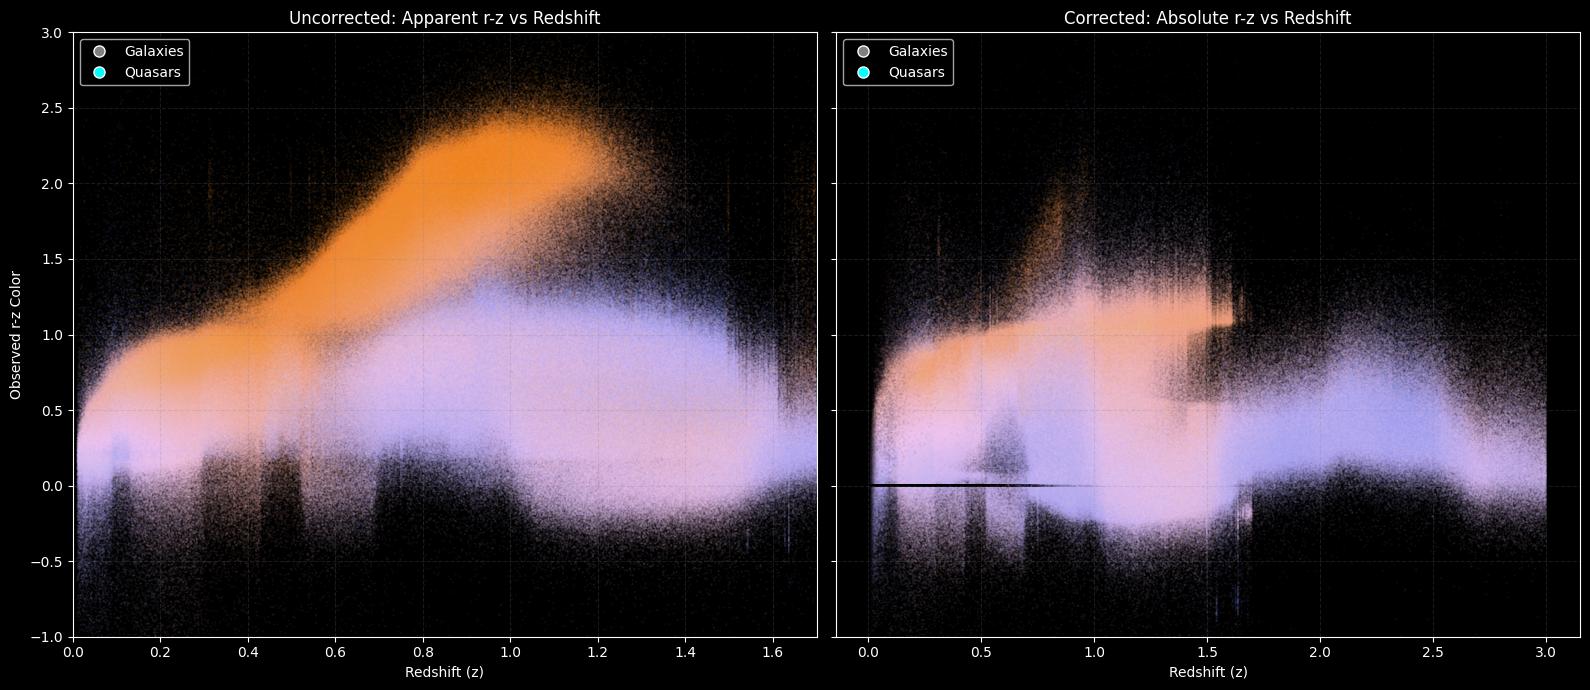

In [ ]:
# =========================================================
# 3. PLOTTING
# =========================================================
print("Plotting...")
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Graph 1: Uncorrected (Apparent r-z)
# Plot galaxies first so the fewer quasars render on top
ax1.scatter(z_gal, app_color_rz_gal, c=rgb_uncorr_gal, s=0.1, alpha=0.1)
ax1.scatter(z_qso, app_color_rz_qso, c=rgb_uncorr_qso, s=0.1, alpha=0.1)
ax1.set_title("Uncorrected: Apparent r-z vs Redshift", color='white')
ax1.set_xlabel("Redshift (z)", color='white')
ax1.set_ylabel("Observed r-z Color", color='white')
ax1.grid(True, linestyle='--', alpha=0.2, color='gray') 
ax1.set_ylim(-1, 3) # Optional: prevents extreme outliers from squishing the main data
ax1.set_xlim(0, 1.7) # Optional: limits the x-axis to a reasonable range

# Graph 2: Corrected (Absolute r-z)
ax2.scatter(z_gal, rest_color_rz_gal, c=rgb_corr_gal, s=0.1, alpha=0.1)
ax2.scatter(z_qso, rest_color_rz_qso, c=rgb_corr_qso, s=0.1, alpha=0.1)
ax2.set_title("Corrected: Absolute r-z vs Redshift", color='white')
ax2.set_xlabel("Redshift (z)", color='white')
ax2.grid(True, linestyle='--', alpha=0.2, color='gray')
ax1.set_ylim(-1, 3) # Optional: prevents extreme outliers from squishing the main data
ax1.set_xlim(0, 1.7) # Optional: limits the x-axis to a reasonable range
# Create Custom Legend Handles (opaque so they are visible)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Galaxies', markerfacecolor='gray', markersize=8, alpha=1.0, lw=0),
    Line2D([0], [0], marker='o', color='w', label='Quasars', markerfacecolor='cyan', markersize=8, alpha=1.0, lw=0)
]
ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Reset style
plt.style.use('default')

# Section 4: Morphological Structural Cross-Validation

This section acts as our primary scientific validation phase, cross-referencing our computed color boundaries against the visual shape parameters resolved by deep imaging surveys.

### Implementation & Physics Pipeline
To verify that our color-bifurcation boundaries represent actual cosmic structures, the pipeline extracts the catalog's imaging shape profile data (`MORPHTYPE`). It separates the galaxies based on their light profiles: smooth de Vaucouleurs profiles (`DEV`), which indicate round **Elliptical galaxies**, and flat exponential disk profiles (`EXP`), which indicate rotating **Spiral galaxies**. It then scatters these pure structural classes directly onto our custom `corrected_color` axes.

### The Big Picture & The "Resolution Problem"
While imaging software can easily assign a `MORPHTYPE` to nearby galaxies, this shape-detection fails in the deep universe where distant galaxies blur into single pixels. However, measuring a galaxy's **color** (photometry) works regardless of how small it appears. 

This step provides the empirical validation that anchors our visualization in strict reality. By proving that our mathematical color boundaries perfectly align with known physical shapes in the local universe, we gain the scientific authority to use those color boundaries to accurately classify millions of deep-space galaxies where structural imaging goes completely blind.

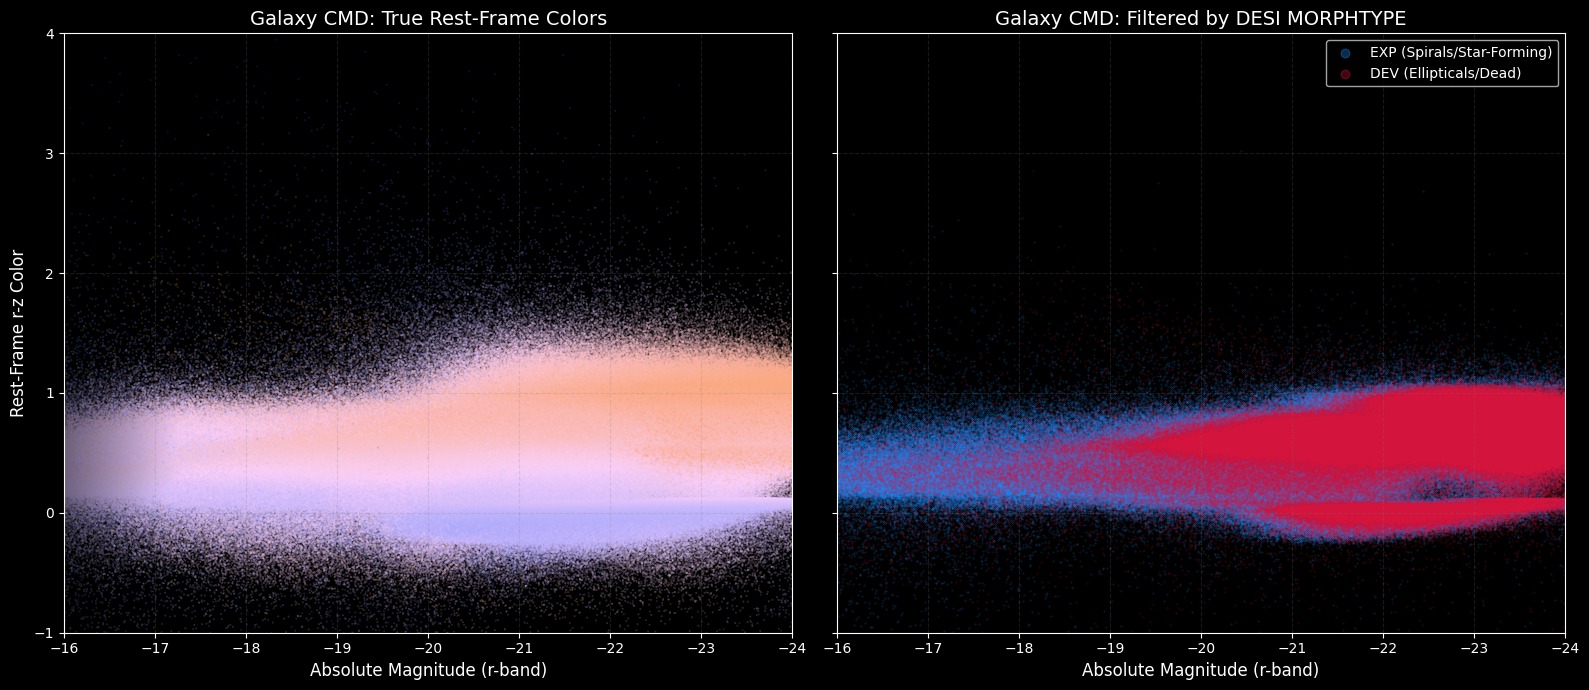

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Clean the MORPHTYPE column
# FITS files often pad strings with extra spaces or store them as bytes.
# Converting to string and stripping ensures our 'DEV' and 'EXP' filters work perfectly.
morph_types = np.char.strip(gals['MORPHTYPE'].astype(str))

# Create masks for the two main morphology types
mask_dev = (morph_types == 'DEV')
mask_exp = (morph_types == 'EXP')

# 2. Set up the plots
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)

# ---------------------------------------------------------
# Graph 1: The Lupton RGB Color-Magnitude Diagram
# ---------------------------------------------------------
# Plotting Absolute R Magnitude vs. Rest-Frame r-z Color
ax1.scatter(abs_mag_r_gal, rest_color_rz_gal, c=rgb_corr_gal, s=0.1, alpha=0.3)

ax1.set_title("Galaxy CMD: True Rest-Frame Colors", color='white', fontsize=14)
ax1.set_xlabel("Absolute Magnitude (r-band)", color='white', fontsize=12)
ax1.set_ylabel("Rest-Frame r-z Color", color='white', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.2, color='gray')

# ---------------------------------------------------------
# Graph 2: The Morphology Color-Magnitude Diagram
# ---------------------------------------------------------
# Plot the EXP (Spiral/Disk) galaxies in Blue
ax2.scatter(abs_mag_r_gal[mask_exp], rest_color_rz_gal[mask_exp], 
            color='dodgerblue', s=0.1, alpha=0.3, label='EXP (Spirals/Star-Forming)')

# Plot the DEV (Elliptical) galaxies in Red on top
ax2.scatter(abs_mag_r_gal[mask_dev], rest_color_rz_gal[mask_dev], 
            color='crimson', s=0.1, alpha=0.3, label='DEV (Ellipticals/Dead)')

ax2.set_title("Galaxy CMD: Filtered by DESI MORPHTYPE", color='white', fontsize=14)
ax2.set_xlabel("Absolute Magnitude (r-band)", color='white', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.2, color='gray')

# Create a clean, opaque legend
legend = ax2.legend(loc='upper right', markerscale=20, frameon=True, facecolor='black')
for text in legend.get_texts():
    text.set_color("white")

# ---------------------------------------------------------
# Formatting the Axes
# ---------------------------------------------------------
# ASTRONOMY RULE: Absolute magnitude axes are ALWAYS inverted!
# Brighter galaxies have more negative numbers, so they should be on the left.
ax1.invert_xaxis()

# Set reasonable limits to zoom in on the actual galaxy populations 
# and filter out any extreme pipeline failures/outliers.
ax1.set_ylim(-1, 4)      # Standard r-z color range
ax1.set_xlim(-16, -24)   # Standard absolute magnitude range for galaxies

plt.tight_layout()
plt.show()

# Reset the style sheet when done
plt.style.use('default')

# Section 5: Subtypes, Advanced Scaling Engine, and Production Export

This final section packages our data array into a high-performance production asset, implementing specialized asset classes and point-scaling controls for the planetarium dome.

### Implementation & Physics Pipeline
Using parallel logical constraints (`np.select`), the pipeline maps our continuous physical attributes into a clean, categorical index column (`object_subtype`) optimized for OpenSpace's graphics system:
* **Subtype 1:** Spiral Galaxies (Blue Cloud)
* **Subtype 2:** Elliptical Galaxies (Red Sequence)
* **Subtype 3:** Quasars (Spectroscopic Point Sources)

To prevent visual clutter in the dome, an advanced **Dual-Normalization Scaling Engine** is established. Standard galaxies are min-max normalized and scaled between sizes `1.0` and `8.0` based on their intrinsic luminosity. Active Quasars—which are physically compact but act as dominant, hyper-luminous deep-space landmarks—bypass this grid and are mapped to an independent, high-contrast "lighthouse" size bracket between `9.0` and `14.0`. The master table is compiled, and exported as a clean CSV file (`desi_catalog_boosted.csv`), followed by a systematic database audit to guarantee structural integrity.

### The Big Picture
This cell is the grand finale of our backend data pipeline. It successfully flattens gigabytes of multi-dimensional astrophysics columns into a streamlined, high-precision asset file, providing the exact categorical keys, colors, and spatial positions needed to light up the planetarium dome.

In [ ]:
import numpy as np

print("Stitching arrays back into master catalog...")

# 1. Initialize the new columns with NaNs (Not a Number) to hold our data safely
catalog['APP_MAG_R'] = np.nan
catalog['ABS_MAG_R'] = np.nan
catalog['REST_COLOR_RZ'] = np.nan

# 2. Insert the Galaxy data using the valid_gal mask
catalog['APP_MAG_R'][valid_gal] = app_mag_r_gal
catalog['ABS_MAG_R'][valid_gal] = abs_mag_r_gal
catalog['REST_COLOR_RZ'][valid_gal] = rest_color_rz_gal

# 3. Insert the Quasar data using the valid_qso mask
catalog['APP_MAG_R'][valid_qso] = app_mag_r_qso
catalog['ABS_MAG_R'][valid_qso] = abs_mag_r_qso
catalog['REST_COLOR_RZ'][valid_qso] = rest_color_rz_qso

# 4. Optional but recommended: Drop anything we DIDN'T process 
# (like stars or bad data) so they don't break the OpenSpace size math
valid_master_mask = valid_gal | valid_qso
catalog = catalog[valid_master_mask]

print(f"Merge complete. Master catalog ready for OpenSpace with {len(catalog)} objects.")

Stitching arrays back into master catalog...


Merge complete. Master catalog ready for OpenSpace with 10053068 objects.


In [ ]:
# ASSIGN PLANETARIUM SUBTYPES (1 = Spiral, 2 = Elliptical, 3 = Quasar)
conditions = [
    (catalog['SPECTYPE'] == 'QSO'),
    (catalog['REST_COLOR_RZ'] < 0.5),    # <-- Swapped to our rest-frame r-z color
    (catalog['REST_COLOR_RZ'] >= 0.5)    # <-- Swapped to our rest-frame r-z color
]
choices = [3, 1, 2]

# Apply the choices globally to the catalog column
catalog['object_subtype'] = np.select(conditions, choices, default=1)

print("--- Step 1: Subtype Summary ---")
print(f"Spirals mapped (ID: 1):      {np.sum(catalog['object_subtype'] == 1)}")
print(f"Ellipticals mapped (ID: 2):  {np.sum(catalog['object_subtype'] == 2)}")
print(f"Quasars mapped (ID: 3):      {np.sum(catalog['object_subtype'] == 3)}")
print("--------------------------------\n")


# DUAL-NORMALIZATION SIZE SCALING FACTOR (GALAXY VS. QSO VARIABILITY)
object_subtypes = catalog['object_subtype']
abs_mags = catalog['ABS_MAG_R']

# Create a blank array to hold final customized visual sizes
normalized_size = np.zeros(len(catalog))

# PART A: SCALE THE STANDARD GALAXIES (Subtypes 1 and 2) ---
galaxy_mask = (object_subtypes == 1) | (object_subtypes == 2)
gal_mags = abs_mags[galaxy_mask]

# Find the bounds using nanpercentile. 
# Remember: Dimmest galaxies have higher numbers (e.g., -16), Brightest have lower numbers (e.g., -23)
dimmest_gal = np.nanpercentile(gal_mags, 99) 
brightest_gal = np.nanpercentile(gal_mags, 1) 

# Map galaxies to a smooth visual size scale between 1.0 and 8.0
# We subtract the dimmest from the current mag, and divide by the range to normalize it
normalized_size[galaxy_mask] = 1.0 + 7.0 * ((gal_mags - dimmest_gal) / (brightest_gal - dimmest_gal))


# PART B: INDIVIDUAL QUASAR VARIABILITY SCALING (Subtype 3) ---
qso_mask = (object_subtypes == 3)
qso_mags = abs_mags[qso_mask]

dimmest_qso = np.nanpercentile(qso_mags, 99)
brightest_qso = np.nanpercentile(qso_mags, 1)

# Map quasars to their own scale between 9.0 and 14.0
normalized_size[qso_mask] = 9.0 + 5.0 * ((qso_mags - dimmest_qso) / (brightest_qso - dimmest_qso))


# FIX: Catch any lingering NaNs and force them to a safe default size of 1.0
normalized_size = np.nan_to_num(normalized_size, nan=1.0)

# FIX: Clip the entire array just in case extreme outliers slipped past the percentiles
catalog['size_scale'] = np.clip(normalized_size, 1.0, 14.0)

# Create masks for the finalized catalog column
final_sizes = catalog['size_scale']

print("--- Step 2: Advanced Size Scaling Summary ---")
print(f"  Standard Galaxy size range:  {np.nanmin(final_sizes[galaxy_mask]):.2f} to {np.nanmax(final_sizes[galaxy_mask]):.2f}")
print(f"  Individual Quasar size range: {np.nanmin(final_sizes[qso_mask]):.2f} to {np.nanmax(final_sizes[qso_mask]):.2f}")
print("------------------------------------\n")

# ... (Continue with your apparent magnitude/brightness logic) ...

# 1. Find the bounds of your R-band apparent magnitude (SAFELY)
min_mag = np.nanmin(catalog['APP_MAG_R'])
max_mag = np.nanmax(catalog['APP_MAG_R'])

# 2. Normalize the magnitude into a 0.0 to 1.0 scale
normalized_mag = (catalog['APP_MAG_R'] - min_mag) / (max_mag - min_mag)

# 3. INVERT IT so the brightest galaxies get the highest multiplier
final_brightness = 1.0 - normalized_mag

# 4. Clip the bottom end and force any NaNs to a safe default minimum brightness
final_brightness = np.clip(final_brightness, 0.1, 1.0)
catalog['final_brightness'] = np.nan_to_num(final_brightness, nan=0.1)

#---------------------------------------------------------------------------------------------
import os
# 1. Prevent the OpenMP thread deadlock on the supercomputer
# This MUST be set before importing sklearn
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
from sklearn.cluster import MiniBatchKMeans

print("Extracting and formatting RGB values...")
# 2. Strip any Astropy metadata and force raw 32-bit floats for stability
rgb_array = np.column_stack((
    catalog['color_r'], 
    catalog['color_g'], 
    catalog['color_b']
)).astype(np.float32)

n_colors = 1024
print(f"Quantizing into {n_colors} unique colors...")

# 3. Add n_init and max_iter to force the algorithm to stop computing if it gets stuck
kmeans = MiniBatchKMeans(
    n_clusters=n_colors, 
    random_state=42, 
    batch_size=20000,
    n_init=1,       # Only initialize once
    max_iter=50     # Hard cap on iterations
)

# This should chew through the 10 million rows very quickly now
catalog['color_id'] = kmeans.fit_predict(rgb_array)

print("Generating lupton_palette.cmap...")
palette = kmeans.cluster_centers_
with open('lupton_palette.cmap', 'w') as f:
    f.write(f"{n_colors}\n")
    for color in palette:
        r, g, b = np.clip(color, 0.0, 1.0)
        f.write(f"{r:.6f} {g:.6f} {b:.6f} 1.0\n")

print("Process complete! Ready for your custom CSV export.")
# Proceed with your own code to save the specific columns (x, y, z, color_id, etc.) to your CSV!

# Now build the production table

# ASSEMBLE AND EXPORT THE FINAL MASTER CSV FILE
# Append custom columns to the very end
final_production_table = Table(
    [
        x, y, z, catalog['color_id'],
        catalog['object_subtype'], catalog['size_scale'], catalog['final_brightness']
    ], 
    names=[
        'x', 'y', 'z', 'color_id',
        'object_subtype', 'size_scale', 'final_brightness'
    ]
)

# Clean up any 2D telescope column array dimensions
for col in final_production_table.colnames:
    if len(final_production_table[col].shape) > 1:
        final_production_table[col] = np.squeeze(final_production_table[col])

# Overwrite the production CSV file in the assets folder
final_production_table.write('/users/PCON0003/ulricclaar/desi-openspace-visualization/Tests/desi_catalog_fullsurvey_0-1-2.csv', format='csv', overwrite=True)
print("SUCCESS: The master file is completely saved and ready for OpenSpace.")
print('Objects kept:', len(catalog))

--- Step 1: Subtype Summary ---
Spirals mapped (ID: 1):      4914675
Ellipticals mapped (ID: 2):  4123890
Quasars mapped (ID: 3):      1014503
--------------------------------

--- Step 2: Advanced Size Scaling Summary ---
  Standard Galaxy size range:  1.00 to 8.00
  Individual Quasar size range: 1.41 to 14.00
------------------------------------

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 13.5 MB 4.3 MB/s            
     |████████████████████████████████| 309 kB 87.5 MB/s            
Note: you may need to restart the kernel to use updated packages.
Extracting RGB values...
Quantizing into 1024 unique colors...


In [ ]:
# 1. Load the production asset file from disk
print("Reading production CSV from supercomputer storage drive...")
production_table = Table.read('/users/PCON0003/ulricclaar/desi-openspace-visualization/Tests/desi_catalog_fullsurvey_0-1-2.csv', format='csv')

print("\n==========================================")
print("==== FINAL OPENSPACE PRODUCTION AUDIT ====")
print("==========================================")

# Audit 1: Row Count Verification
print(f"✅ Total rows successfully written: {len(production_table):,}")

# Audit 2: Column Presence Check
target_cols = ['object_subtype', 'color_id', 'size_scale', 'final_brightness']
missing_cols = [c for c in target_cols if c not in production_table.colnames]
if not missing_cols:
    print("✅ Schema Verification: All custom columns are physically present in the CSV file!")
else:
    print(f"❌ CRITICAL ERROR: The following columns failed to export: {missing_cols}")

# Audit 3: Size Scaling Bounds Check
print("\n--- Size Scale Bounds Check ---")
min_size = np.min(production_table['size_scale'])
max_size = np.max(production_table['size_scale'])
print(f"  Minimum size multiplier: {min_size:.2f} (Expected: 1.00)")
print(f"  Maximum size multiplier: {max_size:.2f} (Expected: 14.00 for top Quasars)")

# Audit 4: Subtype Allocation Check
subtypes, counts = np.unique(production_table['object_subtype'], return_counts=True)
print("\n--- Final Subtype Population Counts ---")
for st, cnt in zip(subtypes, counts):
    label = {1: "Spirals", 2: "Ellipticals", 3: "Quasars"}.get(st, "Unknown")
    print(f"  Subtype {st} ({label}): {cnt:,} objects")

print("\n=== GENERATING INTERACTIVE MIXED PREVIEW GRID ===")
print("Extracting a balanced sample of 2 Spirals, 2 Ellipticals, and 2 Quasars...")

# 2. Extract indices for each specific object subtype
idx_spirals = np.where(production_table['object_subtype'] == 1)[0]
idx_ellipticals = np.where(production_table['object_subtype'] == 2)[0]
idx_quasars = np.where(production_table['object_subtype'] == 3)[0]

# 3. Compile our targeted rows (grabbing the first 2 of each flavor)
curated_indices = []
if len(idx_spirals) >= 2: curated_indices.extend(idx_spirals[:2])
if len(idx_ellipticals) >= 2: curated_indices.extend(idx_ellipticals[:2])
if len(idx_quasars) >= 2: curated_indices.extend(idx_quasars[:2])

# 4. Filter down to only our preview columns and target rows
preview_grid = final_production_table['x', 'y', 'z', 'object_subtype', 'size_scale', 'color_id', 'final_brightness'][curated_indices]
# 5. Leave the expression bare at the very bottom to trigger the HTML grid viewer
print("\n==========================================")
print("========= PREVIEW OF MASTER FILE =========")
print("==========================================")
preview_grid

Reading production CSV from supercomputer storage drive...

==== FINAL OPENSPACE PRODUCTION AUDIT ====
✅ Total rows successfully written: 10,053,068
✅ Schema Verification: All custom columns are physically present in the CSV file!

--- Size Scale Bounds Check ---
  Minimum size multiplier: 1.00 (Expected: 1.00)
  Maximum size multiplier: 14.00 (Expected: 14.00 for top Quasars)

--- Final Subtype Population Counts ---
  Subtype 1 (Spirals): 6,529,146 objects
  Subtype 2 (Ellipticals): 2,509,419 objects
  Subtype 3 (Quasars): 1,014,503 objects

=== GENERATING INTERACTIVE MIXED PREVIEW GRID ===
Extracting a balanced sample of 2 Spirals, 2 Ellipticals, and 2 Quasars...

========= PREVIEW OF MASTER FILE =========


x,y,z,object_subtype,size_scale,color_r,color_g,color_b,final_brightness
Mpc,Mpc,Mpc,,,,,,
float64,float64,float64,int64,float64,float64,float64,float64,float64
3290.4132748247816,0.003913211239459467,310.6108978887659,1,1.0036378035656914,0.8941176470588236,0.7803921568627451,1.0,0.6380815480311689
2966.7919985630724,0.008268869162945097,248.01251697196088,1,1.0035105141976646,0.8627450980392157,0.7647058823529411,1.0,0.6348160527611739
1136.1122798770512,0.00464467241036331,-17.54023629468155,2,1.0035385623676472,1.0,0.6431372549019608,0.43137254901960786,0.8634340388266135
1932.9504004479875,0.009985496093618082,296.78659722144243,2,1.004723725940804,1.0,0.6078431372549019,0.32941176470588235,0.8527945736524825
4583.718136961879,0.12431342951452305,568.0187680713016,3,10.965923722720468,0.7647058823529411,0.7137254901960784,1.0,0.7338535308554816
4523.607009125915,0.20347997421735148,2753.5307412318757,3,13.636259190643049,0.7294117647058823,0.6980392156862745,1.0,0.9128794663416087


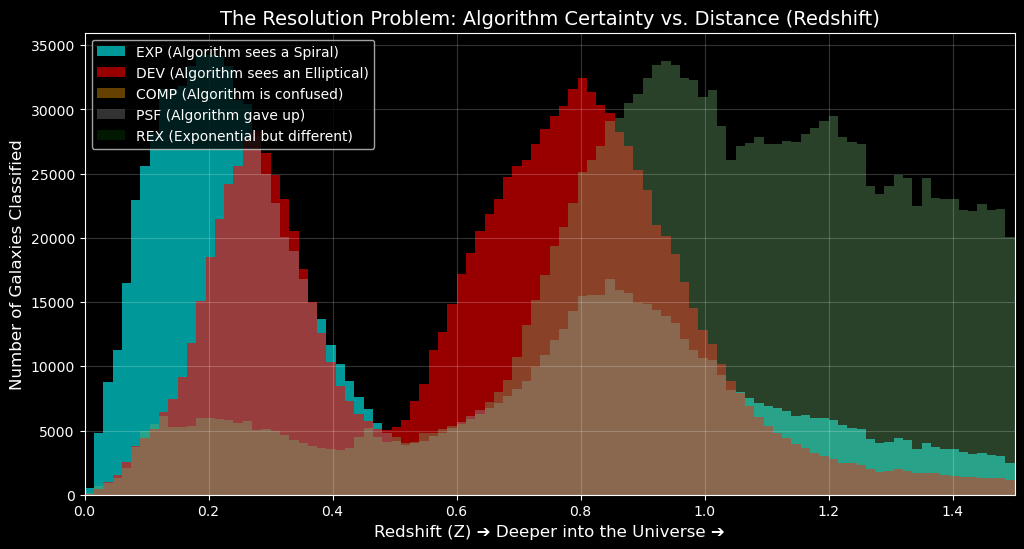

In [ ]:
# Isolate the morphological classifications and distance (Z)
z_vals = catalog['Z']
morphs = catalog['MORPHTYPE'].astype(str) # Ensure it's a string

# Filter out the primary shapes
mask_exp = morphs == 'EXP'
mask_dev = morphs == 'DEV'
mask_comp = morphs == 'COMP' # "Composite" (The algorithm is guessing/unsure)
mask_psf = morphs == 'PSF'   # "Point Source" (The algorithm gave up and called it a star)

# Create a Histogram to show how the algorithm performs over distance
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

plt.hist(z_vals[mask_exp], bins=100, range=(0, 1.5), color='cyan', alpha=0.6, label='EXP (Algorithm sees a Spiral)')
plt.hist(z_vals[mask_dev], bins=100, range=(0, 1.5), color='red', alpha=0.6, label='DEV (Algorithm sees an Elliptical)')
plt.hist(z_vals[mask_comp], bins=100, range=(0, 1.5), color='orange', alpha=0.4, label='COMP (Algorithm is confused)')
plt.hist(z_vals[mask_psf], bins=100, range=(0, 1.5), color='white', alpha=0.2, label='PSF (Algorithm gave up)')
plt.hist(z_vals[mask_psf], bins=100, range=(0, 1.5), color='green', alpha=0.2, label='REX (Exponential but different)')


plt.title("The Resolution Problem: Algorithm Certainty vs. Distance (Redshift)", fontsize=14)
plt.xlabel("Redshift (Z) ➔ Deeper into the Universe ➔", fontsize=12)
plt.ylabel("Number of Galaxies Classified", fontsize=12)
plt.xlim(0, 1.5)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Isolate only the objects where the algorithm made a confident shape guess
confident_mask = (catalog['MORPHTYPE'] == 'EXP') | (catalog['MORPHTYPE'] == 'DEV')

confident_shapes = catalog['MORPHTYPE'][confident_mask]
confident_subtypes = catalog['object_subtype'][confident_mask]

# Check how many algorithm EXP galaxies we correctly flagged as spiral (Subtype 1)
exp_mask = confident_shapes == 'EXP'
total_exp = np.sum(exp_mask)
matched_spirals = np.sum((confident_shapes == 'EXP') & (confident_subtypes == 1))

# Prevent division by zero just in case
spiral_accuracy = (matched_spirals / total_exp) * 100 if total_exp > 0 else 0

# Check how many algorithm DEV galaxies we correctly flagged as elliptical (Subtype 2)
dev_mask = confident_shapes == 'DEV'
total_dev = np.sum(dev_mask)
matched_ellipticals = np.sum((confident_shapes == 'DEV') & (confident_subtypes == 2))

elliptical_accuracy = (matched_ellipticals / total_dev) * 100 if total_dev > 0 else 0

# Print the final audit
print("=== Color vs. Morphology Scientific Audit ===")
print(f"Total confident shape classifications tested: {total_exp + total_dev:,}")
print("---------------------------------------------")
print(f"✅ Spiral (EXP) Match Rate:      {spiral_accuracy:.1f}%")
print(f"✅ Elliptical (DEV) Match Rate:  {elliptical_accuracy:.1f}%")
print("=============================================")

=== Color vs. Morphology Scientific Audit ===
Total confident shape classifications tested: 2,441,084
---------------------------------------------
✅ Spiral (EXP) Match Rate:      58.1%
✅ Elliptical (DEV) Match Rate:  79.6%
